# Определение вероятности мошеннической онлайн-транзакции

## Описание задачи

В данном соревновании необходимо построить модель, определяющую вероятность того, является ли онлайн-транзакция мошеннической.

Целевая переменная — `isFraud`:

- `1` — мошенническая транзакция
- `0` — обычная транзакция

---

## Описание данных

Данные разделены на два файла:

- `transaction` — содержит информацию непосредственно о транзакциях
- `identity` — содержит идентификационную информацию, связанную с транзакциями

Обе таблицы можно объединить по колонке:

- `TransactionID`

> Важно: не для всех транзакций присутствует информация в таблице `identity`, поэтому в этих данных встречается большое количество пропусков.

---

## Описание признаков

Многие признаки в датасете являются анонимизированными.

### Датасет `transaction`

#### Основные признаки

- `TransactionDT` — время, прошедшее с некоторой временной отметки
- `TransactionAmt` — сумма транзакции в USD
- `ProductCD` — код продукта, по которому совершена транзакция

#### Признаки карты и адреса

- `card1`–`card6` — информация о платежной карте:
  - тип карты
  - категория карты
  - банк-эмитент
  - страна и др.
- `addr1`, `addr2` — адресные признаки
- `dist1`, `dist2` — признаки расстояния

#### Email-признаки

- `P_emaildomain` — домен электронной почты покупателя
- `R_emaildomain` — домен электронной почты получателя

#### Группы анонимизированных признаков

- `C1`–`C14` — количественные признаки
  Например, сколько адресов привязано к платежной карте и т.д.
- `D1`–`D15` — временные признаки
  Например, сколько дней прошло с предыдущей транзакции
- `M1`–`M9` — индикаторы различных совпадений
  Например:
  - совпадают ли код телефона и почтовый индекс для биллинга
  - совпадает ли имя на карте с именем, привязанным к адресу
- `V1`–`V45` — вручную сгенерированные признаки на основе ранжирования, подсчётов и других методов

#### Категориальные признаки

- `ProductCD`
- `card1`–`card6`
- `addr1`, `addr2`
- `P_emaildomain`
- `R_emaildomain`
- `M1`–`M9`

---

### Датасет `identity`

#### Анонимизированные признаки

- `id_01`–`id_38`

#### Признаки устройства

- `DeviceType` — тип устройства
- `DeviceInfo` — информация об устройстве

#### Категориальные признаки

- `DeviceType`
- `DeviceInfo`
- `id_12`–`id_38`

---

## Бейзлайны

Для решения задачи можно использовать следующие стартовые материалы:

- **EDA**
- **Baseline (LightGBM)**
- **Baseline (LightGBM + Feature Engineering)**

---

## Идеи для дальнейшего улучшения решения

### 1. Продумать валидационную стратегию

Поскольку данные содержат временные признаки, важно выбрать корректную схему валидации, которая будет хорошо отражать реальное качество модели на тесте.

### 2. Подобрать гиперпараметры модели

Можно попробовать:

- `LightGBM`
- `XGBoost`
- `CatBoost`

### 3. Провести более глубокий анализ данных

Полезно исследовать:

- скрытые взаимосвязи между признаками
- связь признаков с целевой переменной
- возможные закономерности в анонимизированных признаках

### 4. Выполнить feature engineering

Например:

- создать агрегаты
- обработать пропуски
- закодировать категориальные признаки
- отобрать наиболее полезные признаки

### 5. Использовать ансамбли моделей

Для повышения качества можно построить несколько разных, слабо коррелирующих моделей и применить:

- блендинг
- стекинг

---

## Метрика качества

Качество решения оценивается с помощью метрики:

$$
\text{AUC-ROC}
$$

Ответом для каждой транзакции должна быть **вероятность** того, что она является мошеннической, то есть число от `0` до `1`.

---

## Формат submission-файла

Для каждого значения `TransactionID` в тестовых данных необходимо предсказать вероятность для столбца `isFraud`.

### Требования к файлу

Submission-файл должен содержать две колонки:

- `TransactionID`
- `isFraud`

где `isFraud` — это оценка вероятности принадлежности транзакции к классу мошеннических операций.

### Пример формата

```text
TransactionID,isFraud
3404559,0.5
3404560,0.5
3404561,0.5
3404562,0.5
3404563,0.5

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from tqdm import tqdm

sns.set()

%matplotlib inline

In [2]:
INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, '/Users/slvic/ANYA/ML_Fraud_Detection/data/train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, '/Users/slvic/ANYA/ML_Fraud_Detection/data/train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, '/Users/slvic/ANYA/ML_Fraud_Detection/data/test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, '/Users/slvic/ANYA/ML_Fraud_Detection/data/test_identity.csv'))

In [3]:
train_transaction.shape, train_identity.shape, test_transaction.shape, test_identity.shape

((417559, 394), (110666, 41), (172981, 393), (33567, 41))

Отнюдь не для всех транзакций есть информация из `identity`.

In [4]:
train_transaction.isnull().mean().sort_values(ascending=False).rename('% of NaNs')[:20]

D7       0.935468
dist2    0.929864
D13      0.893510
D14      0.891417
D12      0.885628
D6       0.872928
D9       0.864560
D8       0.864560
V143     0.843146
V156     0.843146
V155     0.843146
V154     0.843146
V153     0.843146
V152     0.843146
V151     0.843146
V149     0.843146
V150     0.843146
V158     0.843146
V148     0.843146
V147     0.843146
Name: % of NaNs, dtype: float64

Итак, в данных есть признаки с большим числом пропусков.

Объединим transaction и identity в одну таблицу:

In [5]:
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
y_train = df_train['isFraud'].astype("uint8").copy()
df_train.shape

(417559, 434)

In [6]:
del train_transaction, train_identity

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417559 entries, 0 to 417558
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.4+ GB


In [10]:
def reduce_mem_usage(df):
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in tqdm(df.columns):
        if df[col].dtype != object:  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            col_max_value = df[col].max()
            col_min_value = df[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(df[col]).all():
                NAlist.append(col)
                df[col].fillna(col_min_value - 1, inplace=True)

            # Пересчитываем min/max после заполнения NaN
            col_max_value = df[col].max()
            col_min_value = df[col].min()

            # test if column can be converted to an integer
            col_as_int = df[col].fillna(0).astype(np.int64)
            diff = (df[col] - col_as_int)
            diff = diff.sum()
            if np.abs(diff) < 0.01:
                IsInt = True

            # Make Integer/unsigned Integer datatypes
            if IsInt:
                if col_min_value >= 0:
                    if col_max_value < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif col_max_value < 65535:
                        df[col] = df[col].astype(np.uint16)
                    elif col_max_value < 4294967295:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if col_min_value > np.iinfo(np.int8).min and col_max_value < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif col_min_value > np.iinfo(np.int16).min and col_max_value < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif col_min_value > np.iinfo(np.int32).min and col_max_value < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif col_min_value > np.iinfo(np.int64).min and col_max_value < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)

            # Make float datatypes 32 bit
            else:
                df[col] = df[col].astype(np.float32)

    return df, NAlist

In [11]:
df_train, df_train_NAlist = reduce_mem_usage(df_train)

  0%|          | 0/434 [00:00<?, ?it/s]/var/folders/tx/hr7dgt1j4fz2pk5ps86b4szw0000gn/T/ipykernel_89926/886674328.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(col_min_value - 1, inplace=True)
/var/folders/tx/hr7dgt1j4fz2pk5ps86b4szw0000gn/T/ipykernel_89926/886674328.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obje

In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417559 entries, 0 to 417558
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(80), int16(30), int8(202), object(31), uint16(22), uint32(3), uint8(66)
memory usage: 379.1+ MB


In [13]:
df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')
df_test.shape

(172981, 433)

In [14]:
del test_transaction, test_identity

In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172981 entries, 0 to 172980
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), object(31)
memory usage: 571.4+ MB


In [16]:
df_test, df_test_NAlist = reduce_mem_usage(df_test)

  0%|          | 0/433 [00:00<?, ?it/s]/var/folders/tx/hr7dgt1j4fz2pk5ps86b4szw0000gn/T/ipykernel_89926/886674328.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(col_min_value - 1, inplace=True)
/var/folders/tx/hr7dgt1j4fz2pk5ps86b4szw0000gn/T/ipykernel_89926/886674328.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obje

In [17]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172981 entries, 0 to 172980
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float32(78), int16(40), int8(229), object(31), uint16(24), uint32(3), uint8(28)
memory usage: 157.9+ MB


Данные сильно несбалансированы:

In [18]:
y_train.value_counts()

isFraud
0    402838
1     14721
Name: count, dtype: int64

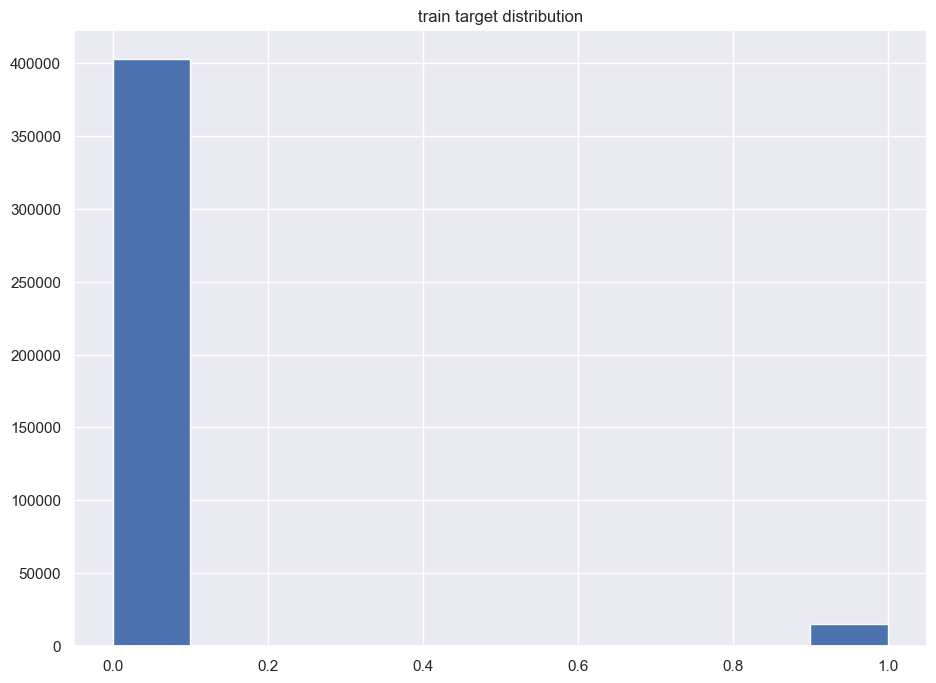

In [19]:
plt.figure(figsize=(11, 8))
plt.title('train target distribution')
plt.hist(y_train)
plt.show()

Можно заметить, что данные содержат признак, отвечающий за момент времени совершения транзакции - 'TransactionDT'. Изучим его подробнее.

In [20]:
df_train['TransactionDT'].min(), df_test['TransactionDT'].max(), df_test['TransactionDT'].max() - df_train['TransactionDT'].min()

(np.uint32(86400), np.uint32(15811131), np.uint32(15724731))

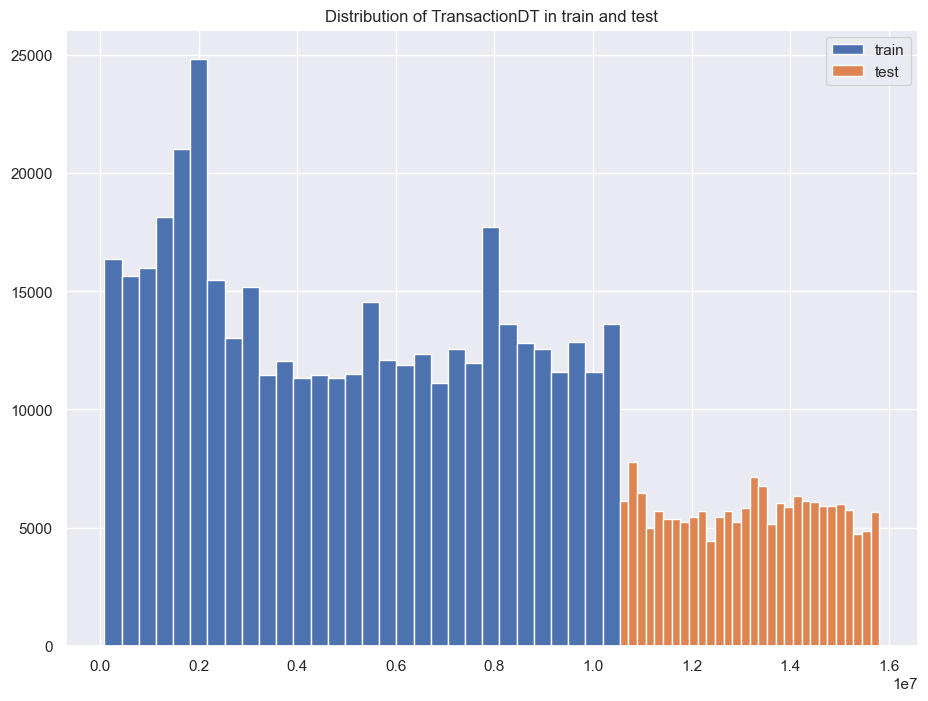

In [21]:
plt.figure(figsize=(11, 8))
plt.title('Distribution of TransactionDT in train and test')
plt.hist(df_train['TransactionDT'], label='train', bins=30)
plt.hist(df_test['TransactionDT'], label='test', bins=30)
plt.legend(loc='best')
plt.show()

Можно предположить, что время для этого признака измеряется в секундах, тогда похоже на то, что данные из трейна и теста - это данные за полгода.

In [22]:
(df_test['TransactionDT'].max() - df_train['TransactionDT'].min()) / (3600 * 24)

np.float64(181.99920138888888)

Также, если время измеряется в секундах, то, судя по всему, обучающая часть выборки включает в себя данные за 4 месяца, а тестовая - за следующие 2:

In [23]:
(df_train['TransactionDT'].max() - df_train['TransactionDT'].min()) / (3600 * 24), (df_test['TransactionDT'].max() - df_test['TransactionDT'].min()) / (3600 * 24)

(np.float64(120.99996527777778), np.float64(60.998900462962965))

Построим распределения различных признаков.

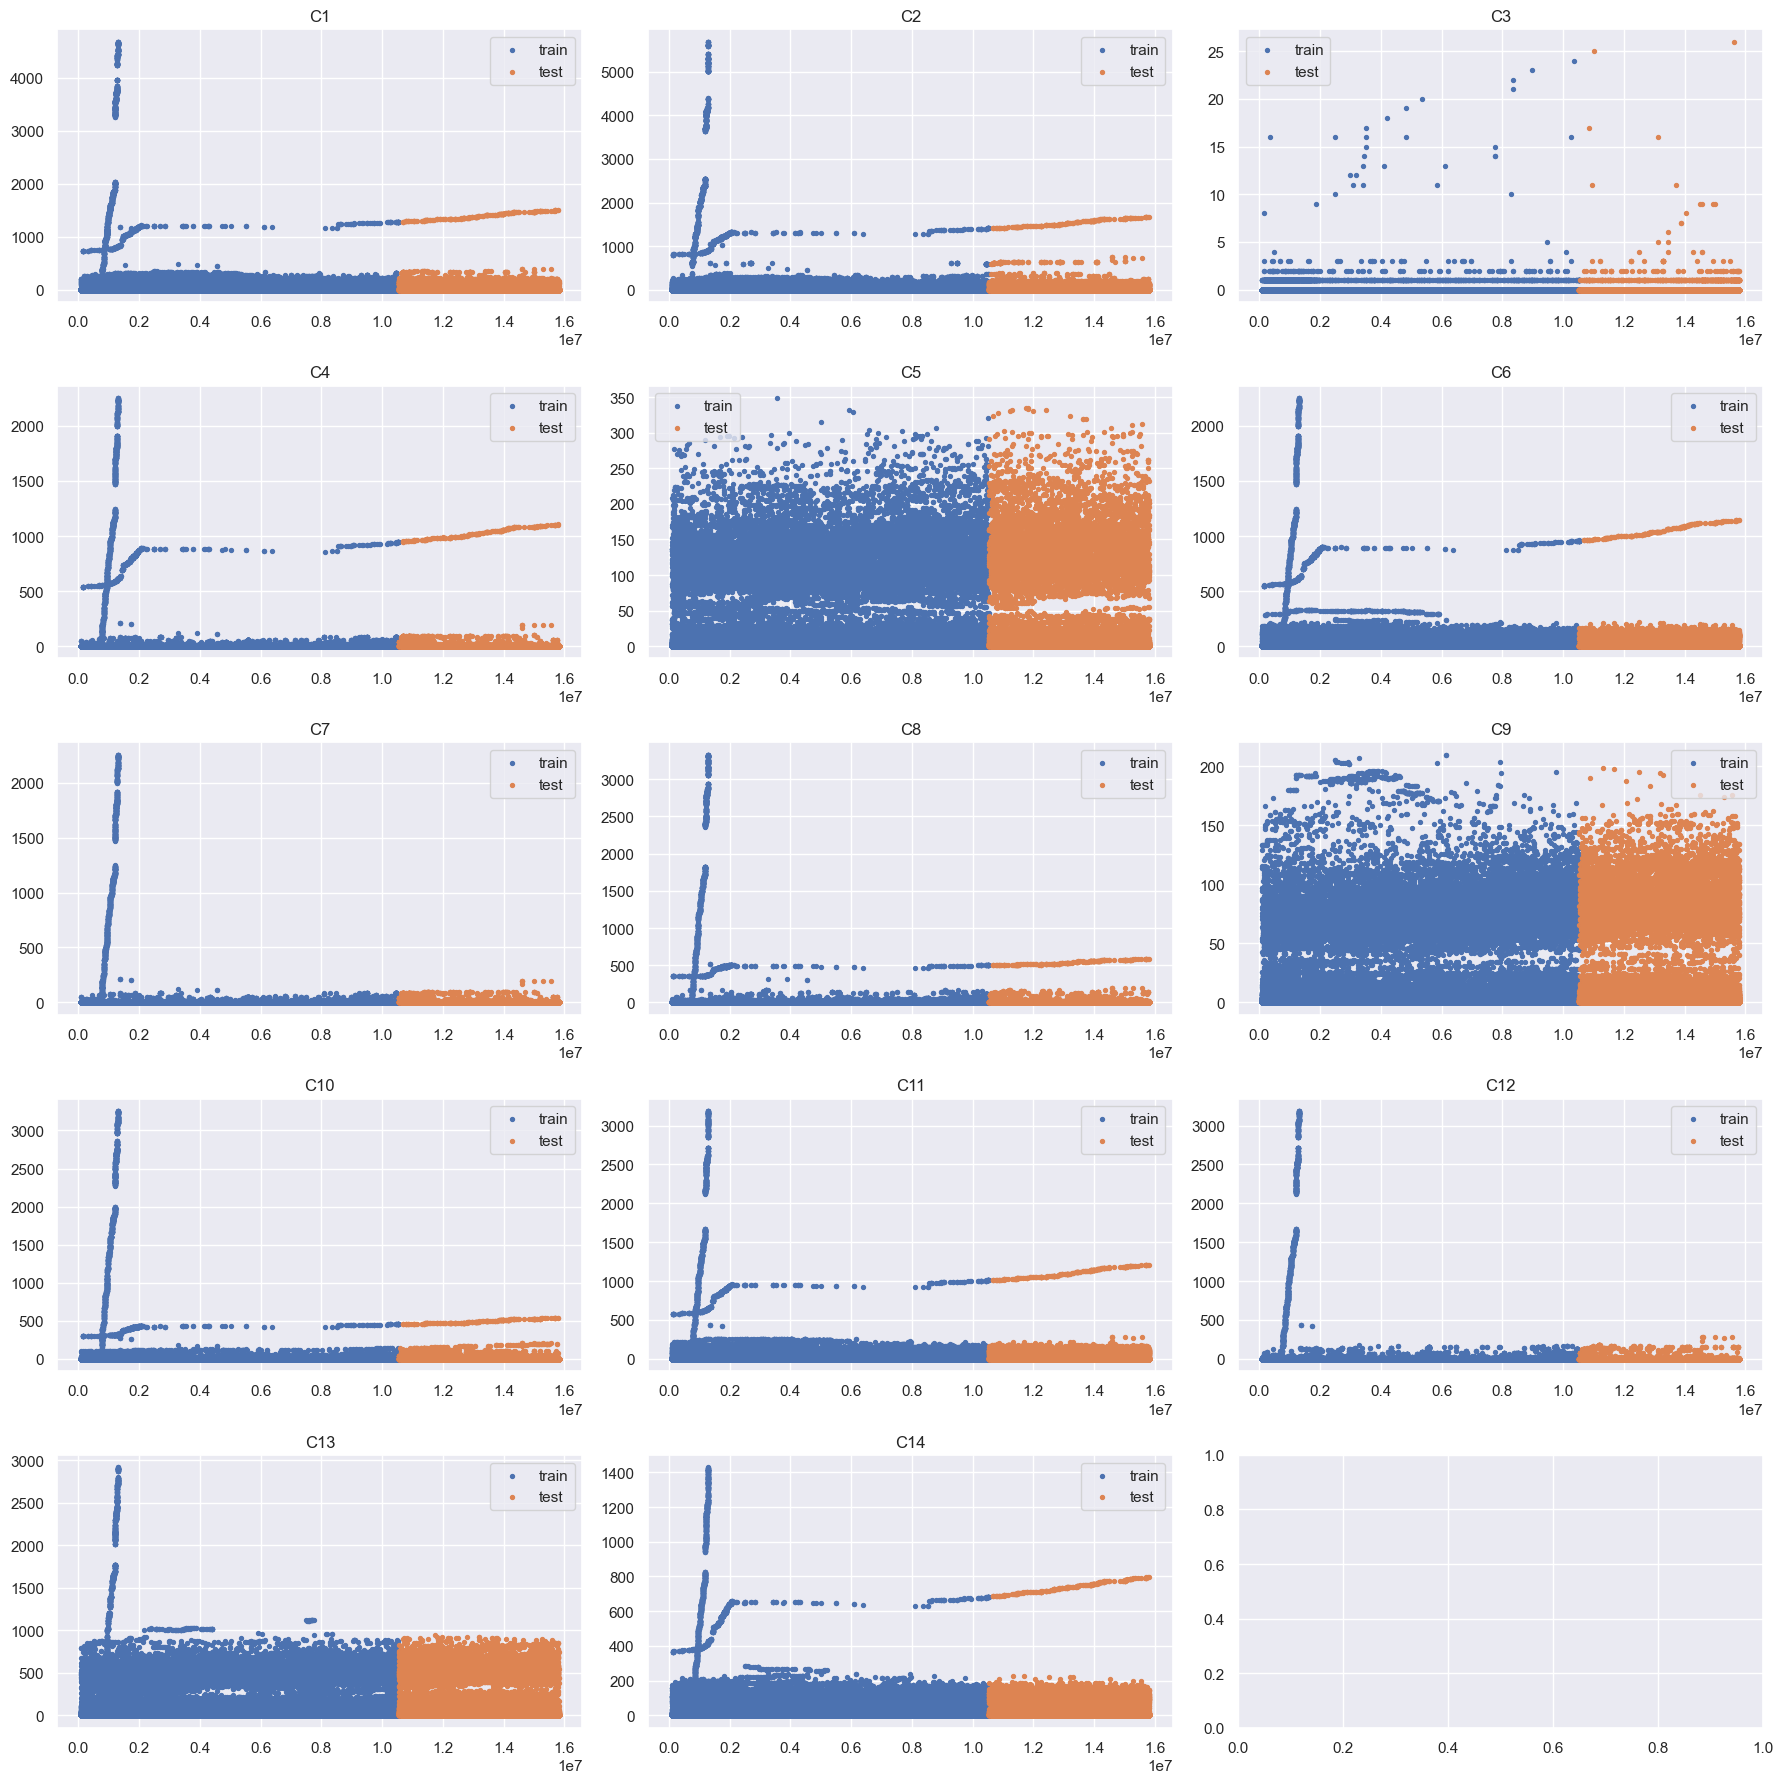

CPU times: user 12.5 s, sys: 637 ms, total: 13.1 s
Wall time: 13.1 s


In [24]:
%%time

c_features = [col for col in df_train.columns if col.startswith('C')]
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 18))
for i in range(len(c_features)):
    col = c_features[i]
    j1 = i // 3
    j2 = i % 3
    ax = axes[j1, j2]
    ax.set_title(col)
    ax.scatter(df_train['TransactionDT'], df_train[col], s=8, label='train')
    ax.scatter(df_test['TransactionDT'], df_test[col], s=8, label='test')
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

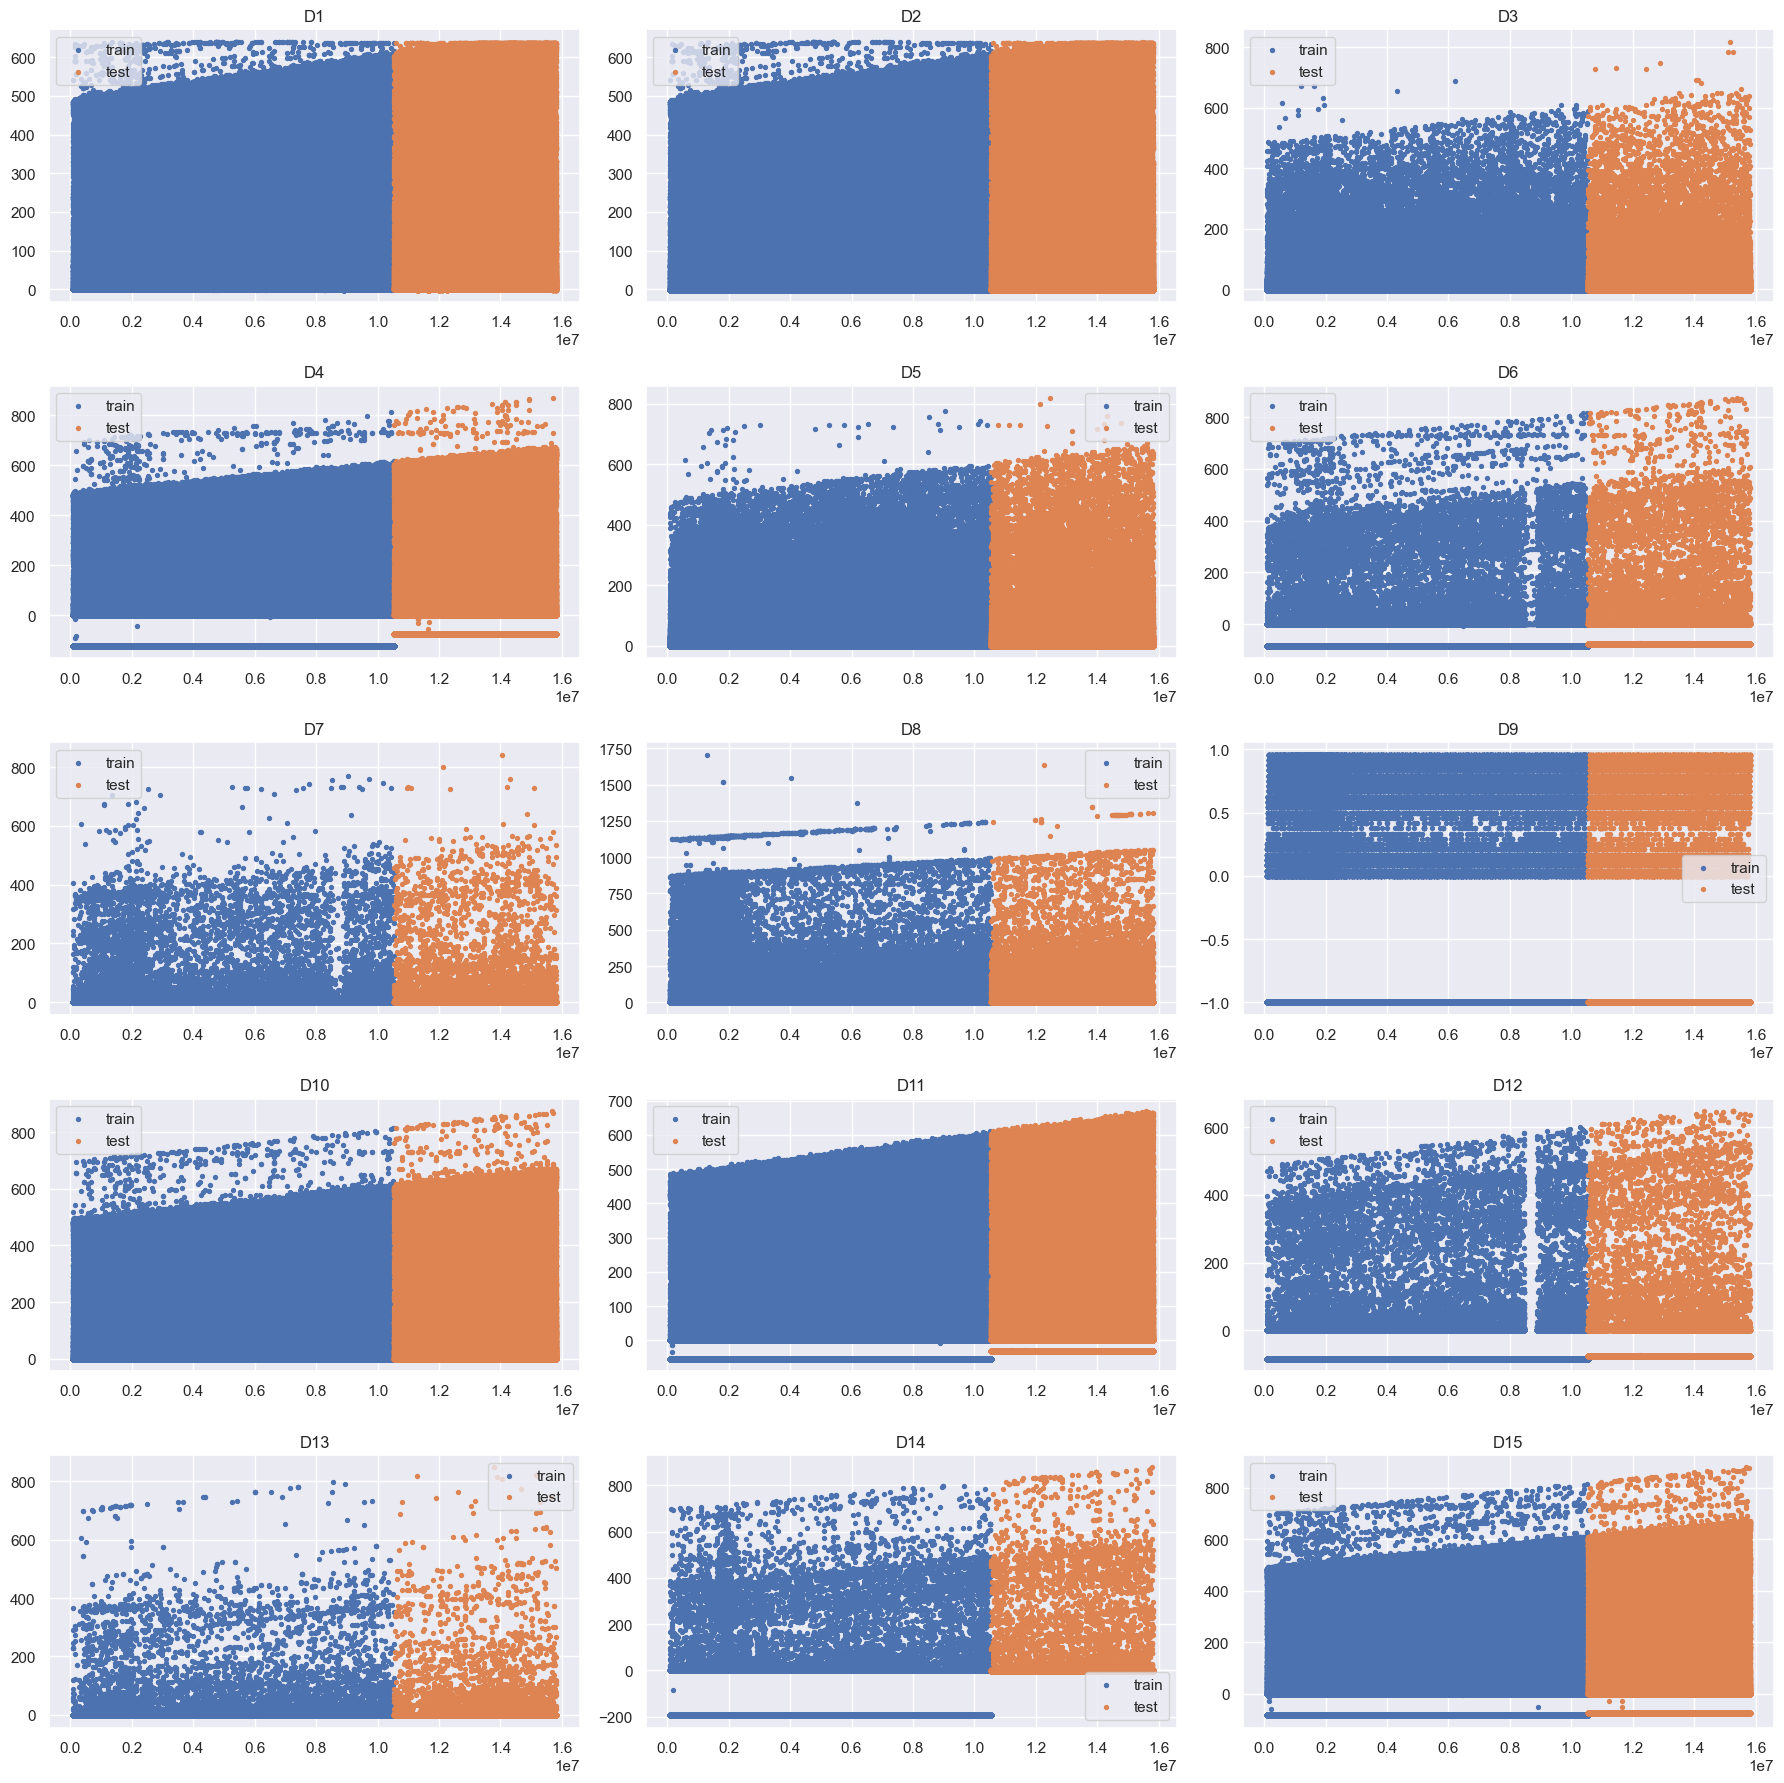

CPU times: user 32.5 s, sys: 1.57 s, total: 34.1 s
Wall time: 34.1 s


In [25]:
%%time

d_features = [col for col in df_train.columns if col.startswith('D')][:-2]
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 18))
for i in range(len(d_features)):
    col = d_features[i]
    j1 = i // 3
    j2 = i % 3
    ax = axes[j1, j2]
    ax.set_title(col)
    ax.scatter(df_train['TransactionDT'], df_train[col], s=8, label='train')
    ax.scatter(df_test['TransactionDT'], df_test[col], s=8, label='test')
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

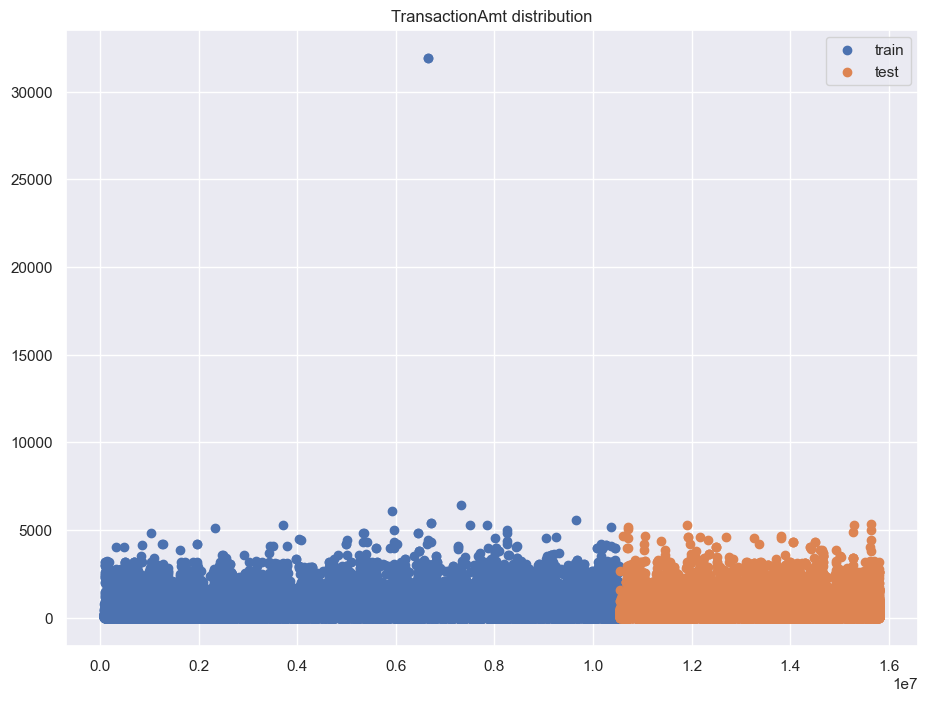

In [26]:
plt.figure(figsize=(11, 8))
plt.title('TransactionAmt distribution')
plt.scatter(df_train['TransactionDT'], df_train['TransactionAmt'], label='train')
plt.scatter(df_test['TransactionDT'], df_test['TransactionAmt'], label='test')
plt.legend(loc='best')
plt.show()

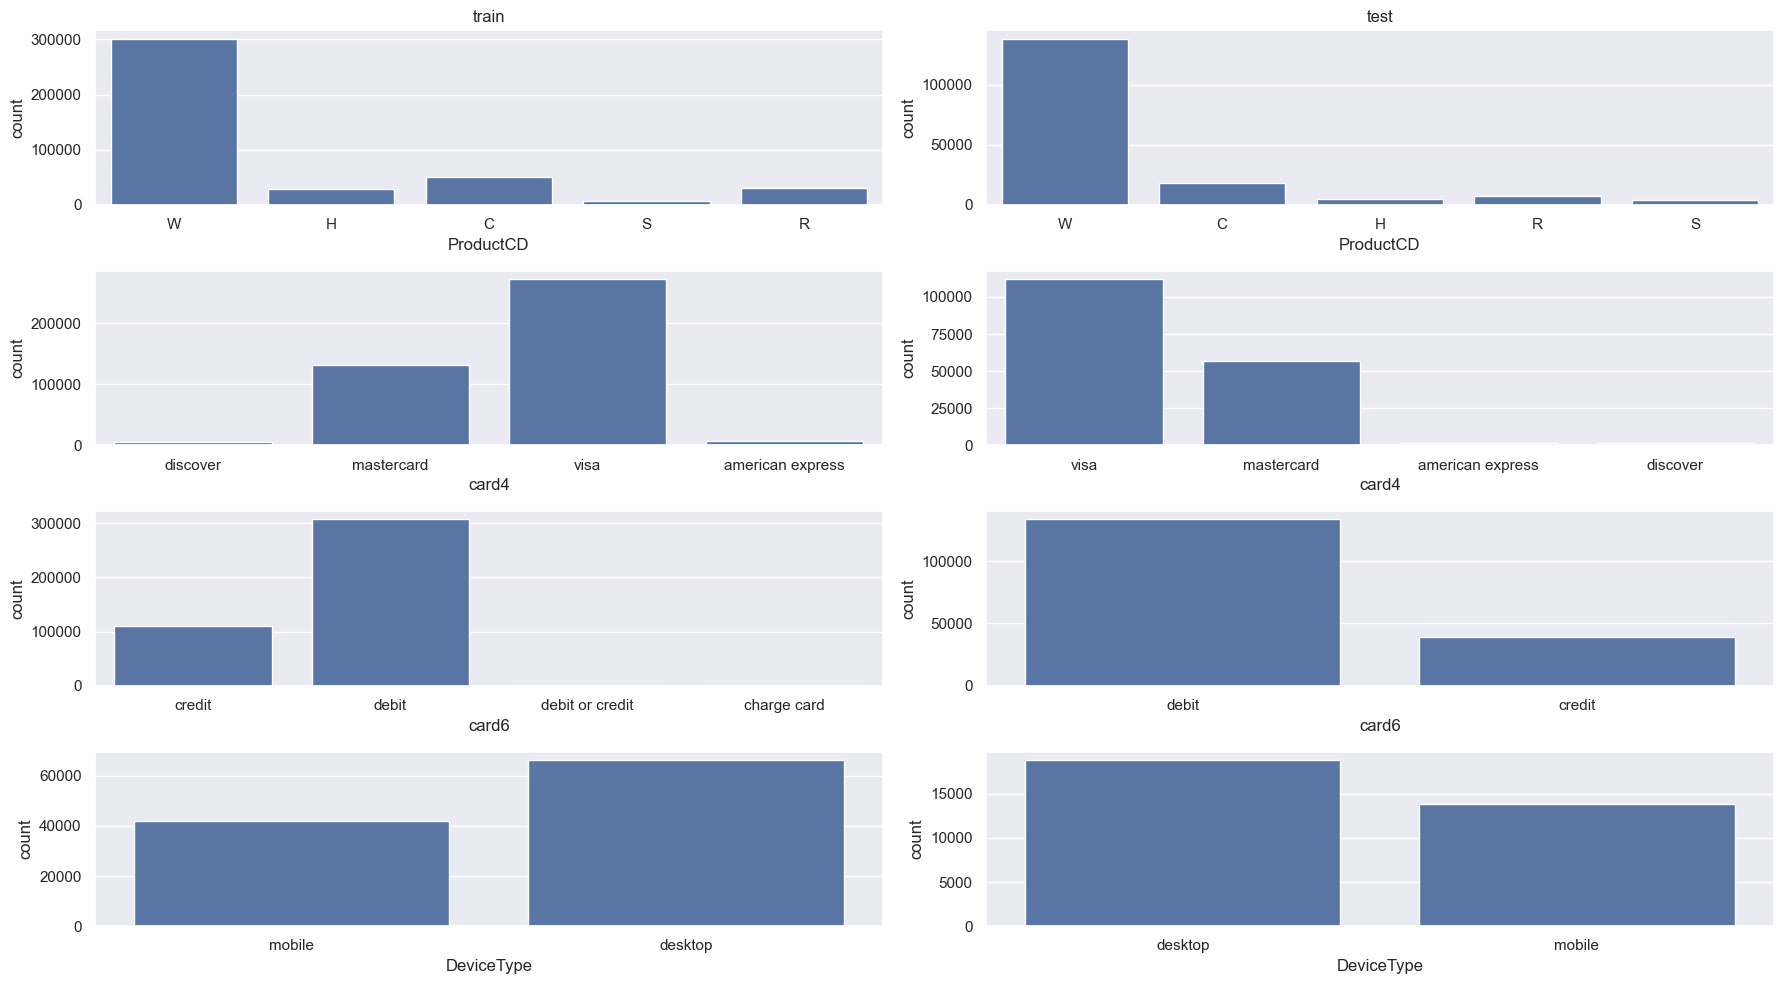

CPU times: user 1.41 s, sys: 27.8 ms, total: 1.44 s
Wall time: 1.44 s


In [27]:
%%time

cat_fts = ['ProductCD', 'card4', 'card6', 'DeviceType']
fig, ax = plt.subplots(nrows=len(cat_fts), ncols=2, figsize=(18, 10))
ax[0, 0].set_title('train')
ax[0, 1].set_title('test')
for i in range(len(cat_fts)):
    col = cat_fts[i]
    sns.countplot(x=col, ax=ax[i, 0], data=df_train)
    sns.countplot(x=col, ax=ax[i, 1], data=df_test)
plt.tight_layout()
plt.show()

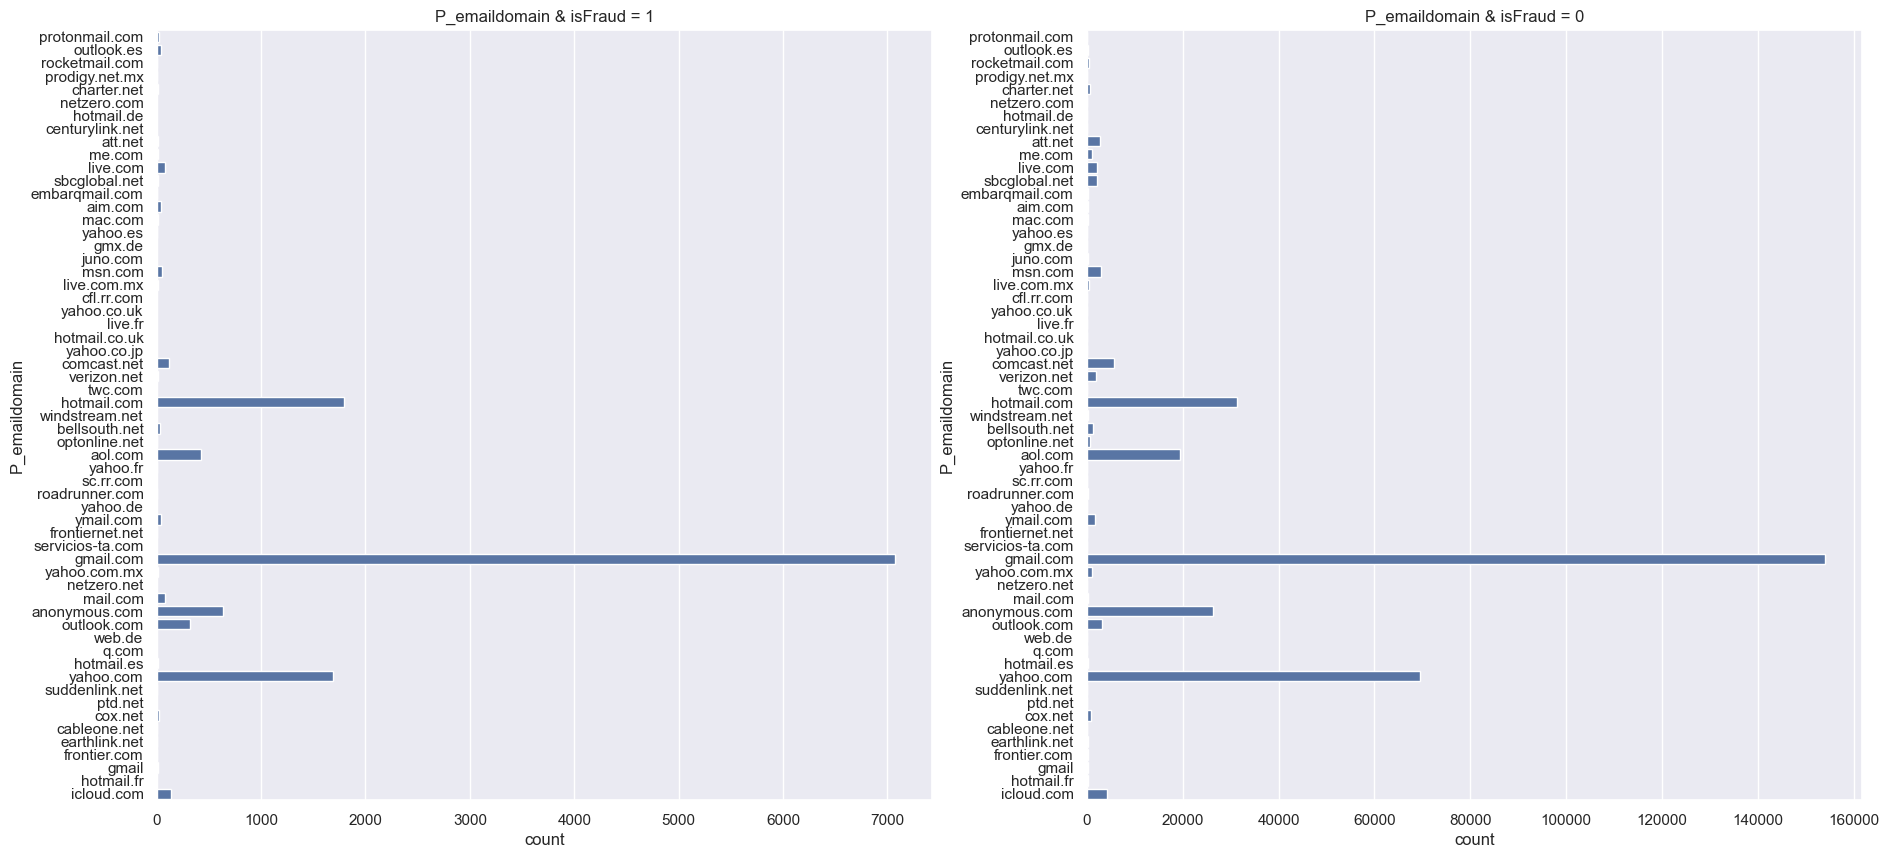

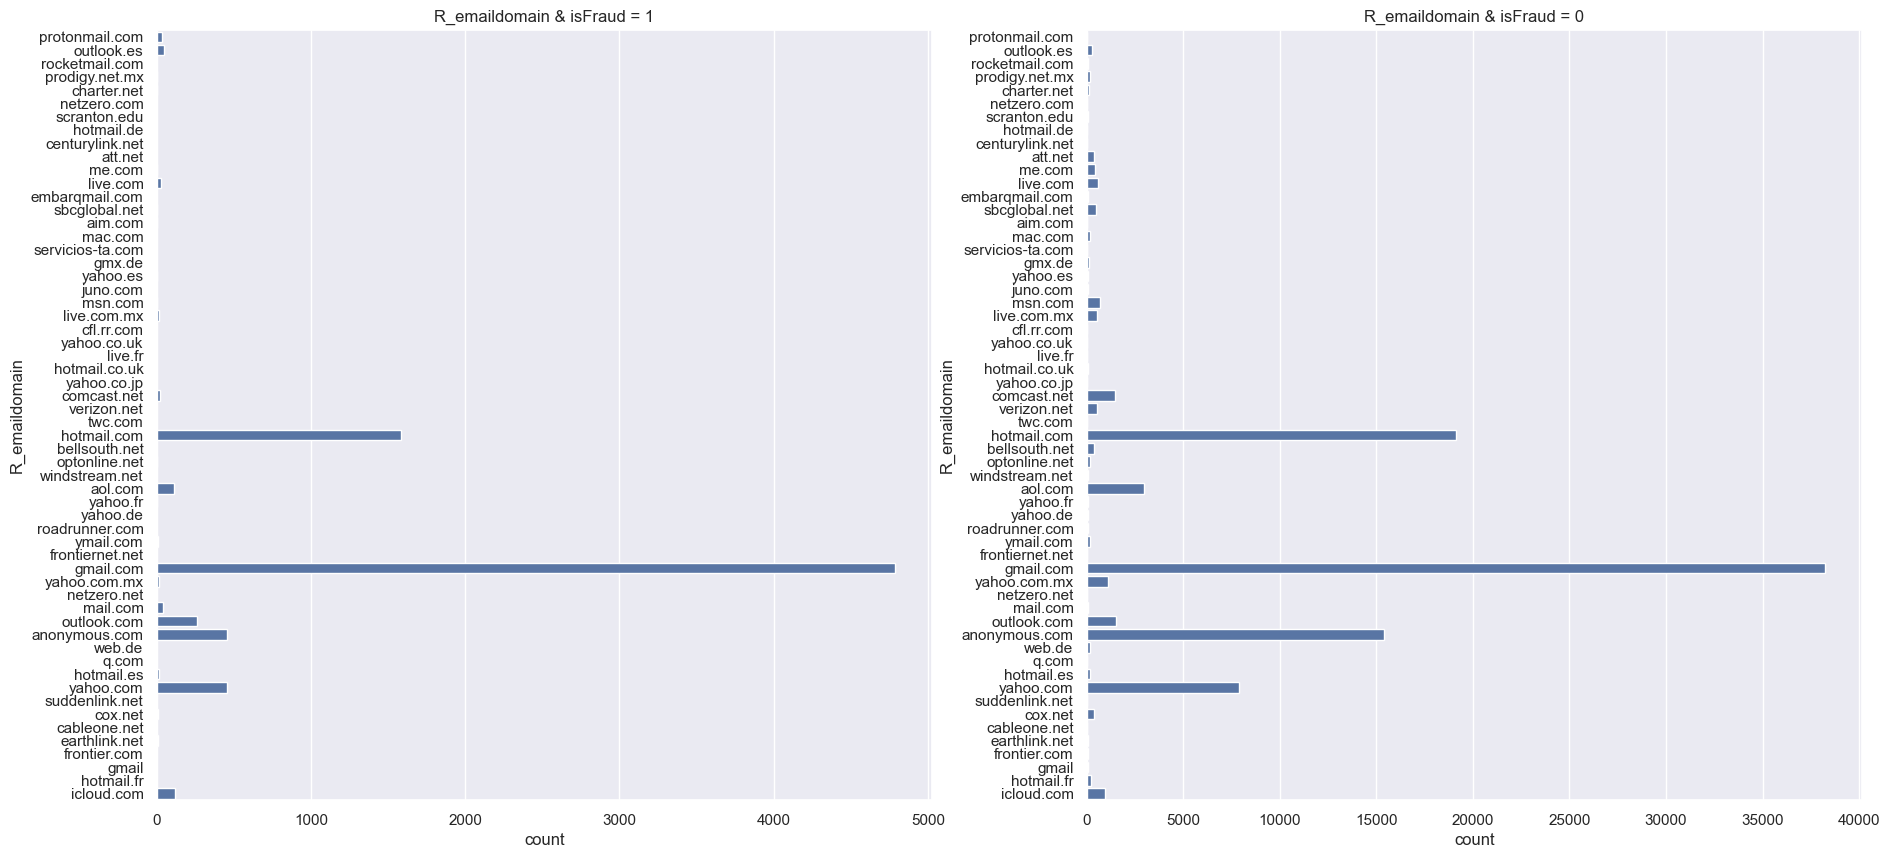

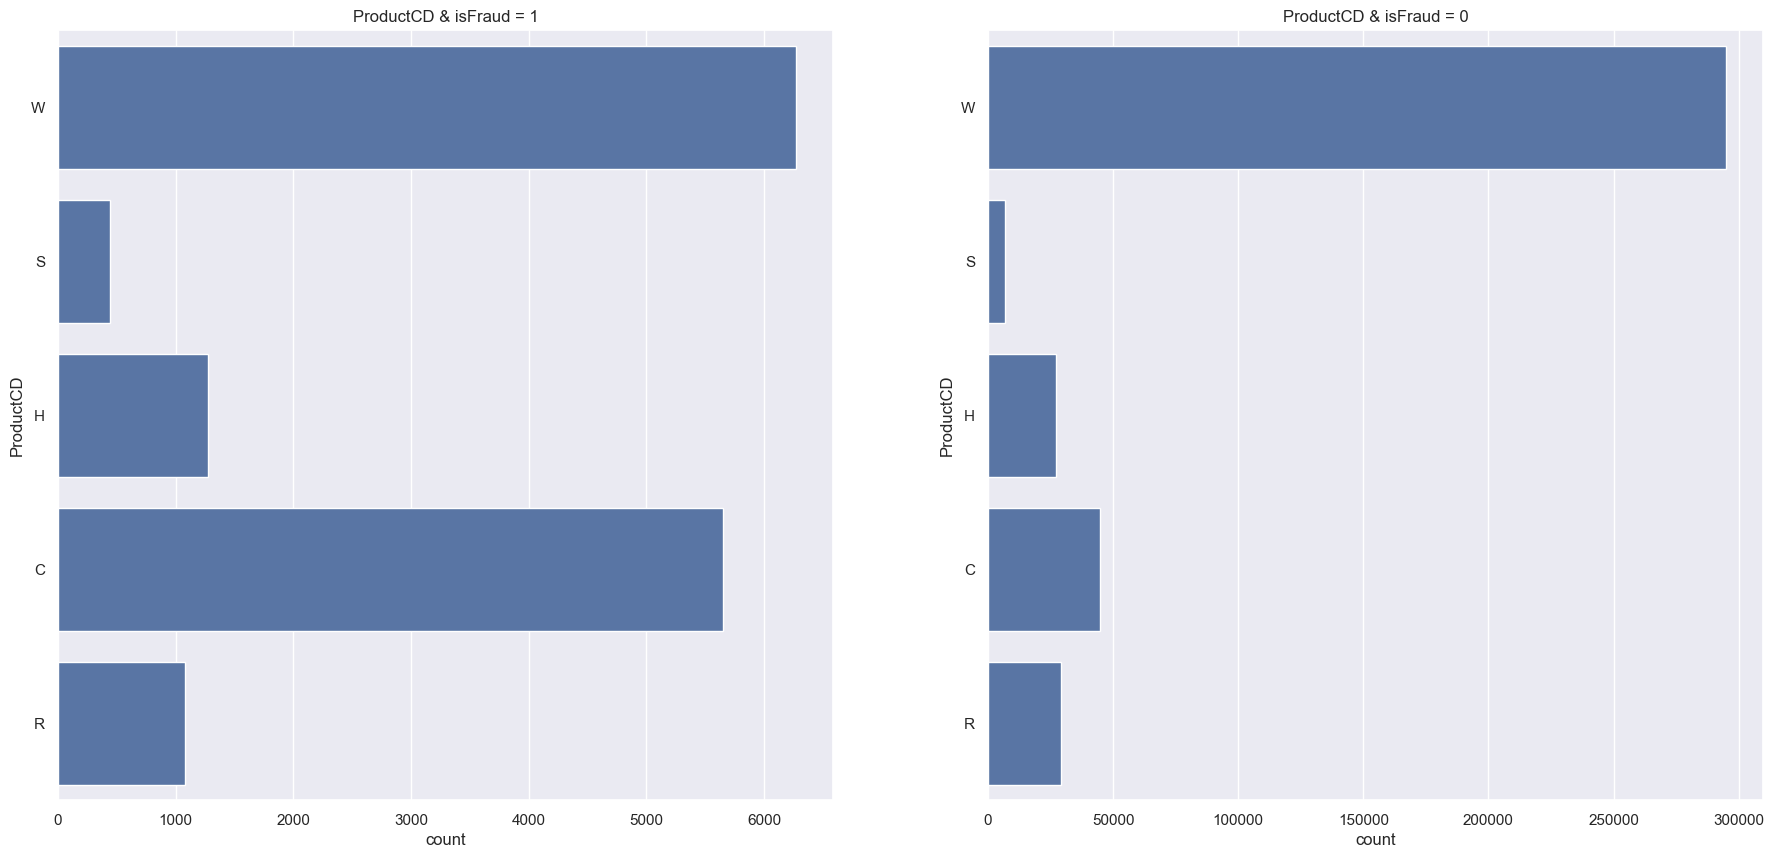

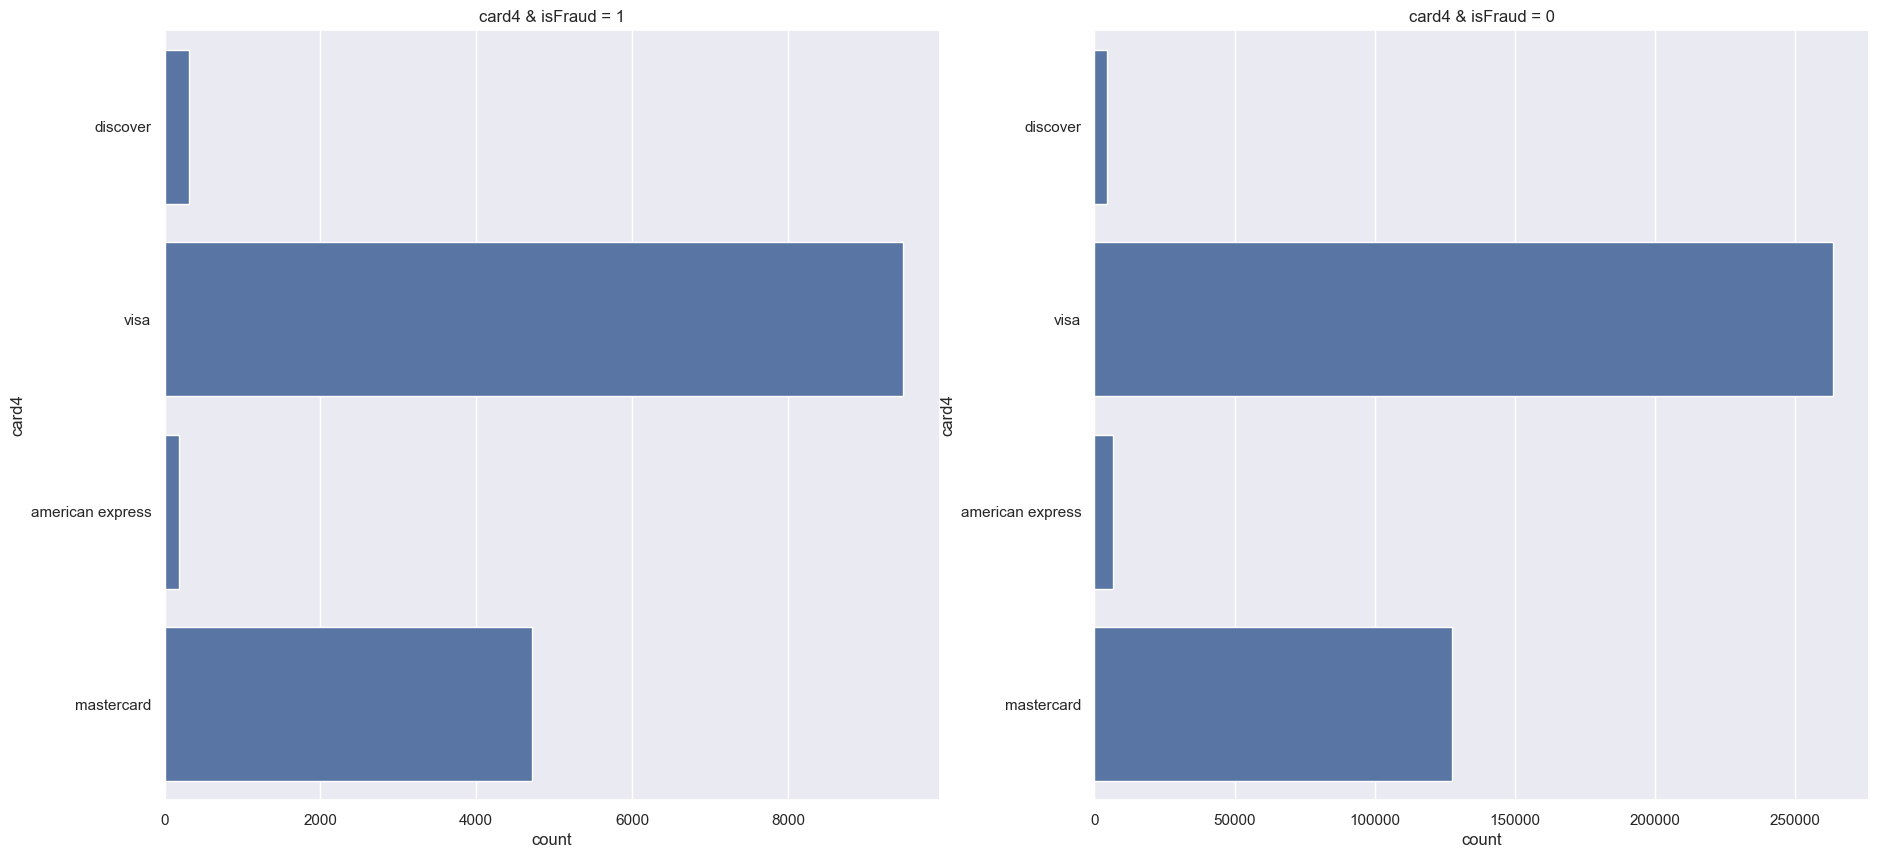

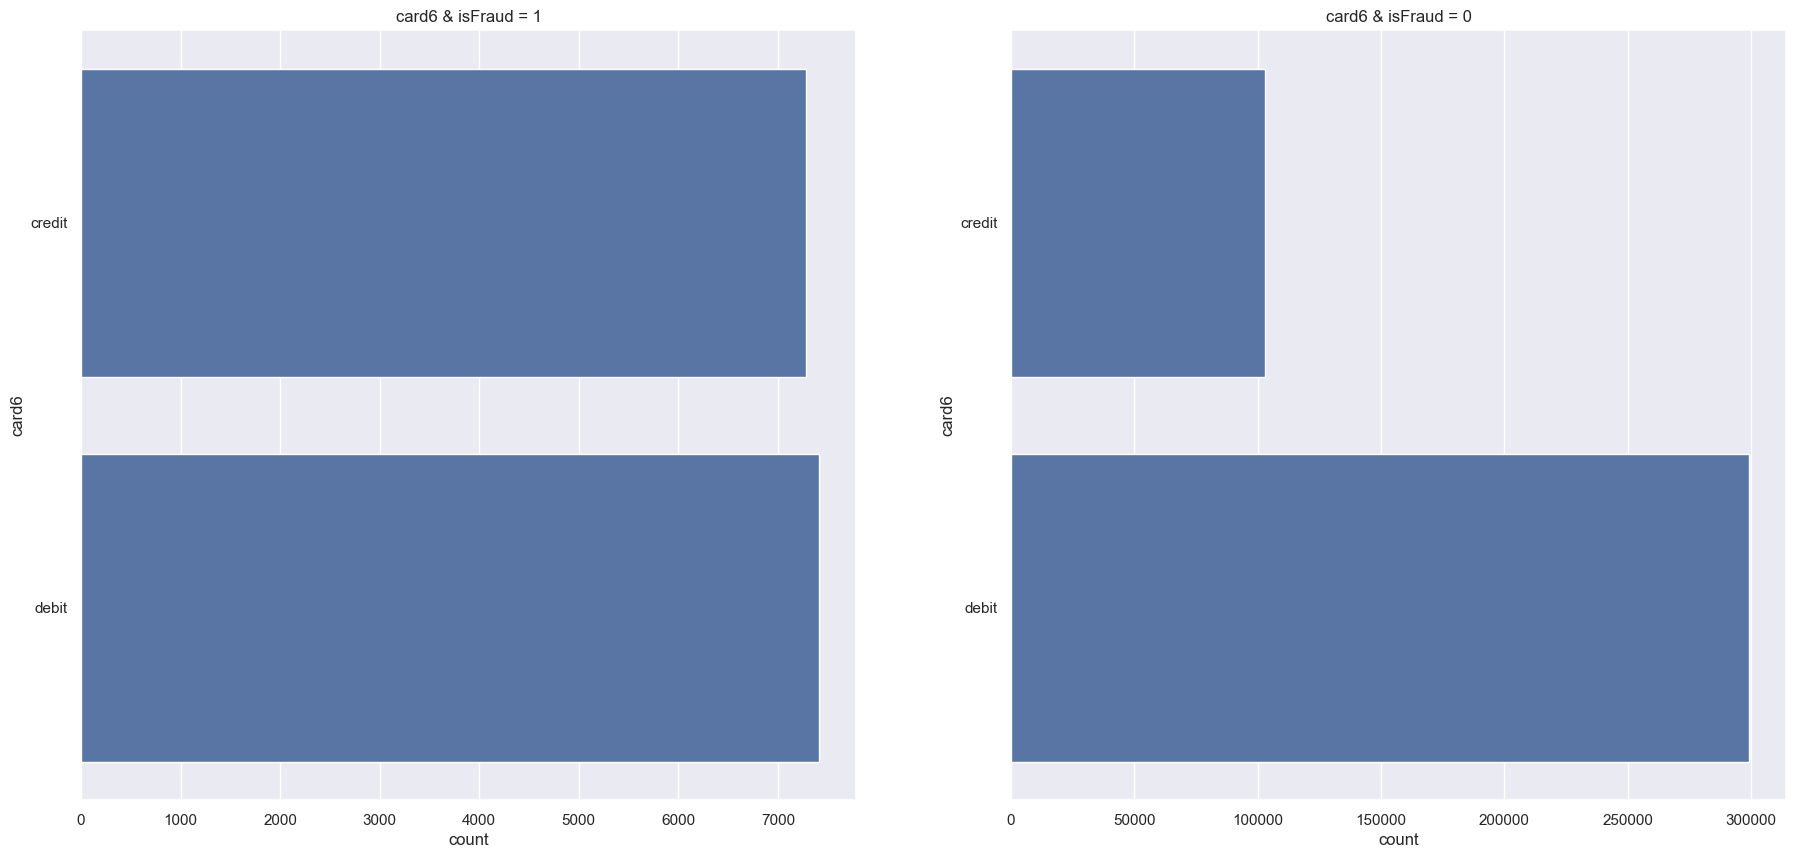

CPU times: user 3.14 s, sys: 116 ms, total: 3.25 s
Wall time: 3.25 s


In [28]:
%%time

cols_target = ['P_emaildomain', 'R_emaildomain', 'ProductCD', 'card4', 'card6']

for col in cols_target:
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))
    unique_values = [x for x in list(set(df_train[col].values).intersection(set(df_test[col].values))) if str(x) != 'nan']
    sns.countplot(y=col, ax=ax[0], data=df_train.loc[df_train['isFraud'] == 1], order=unique_values)
    ax[0].set_title(col + ' & isFraud = 1')
    sns.countplot(y=col, ax=ax[1], data=df_train.loc[df_train['isFraud'] == 0], order=unique_values)
    ax[1].set_title(col + ' & isFraud = 0')
    plt.show()

# Feature Engineering

In [29]:
from sklearn.preprocessing import LabelEncoder

def feature_engineering(df):
    df = df.copy()

    # Временные признаки из TransactionDT
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['day'] = df['TransactionDT'] // (3600 * 24)

    # Логарифм суммы транзакции
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

    # Дробная часть суммы (психологическое ценообразование)
    df['TransactionAmt_decimal'] = df['TransactionAmt'] - df['TransactionAmt'].astype(int)

    # Агрегаты по карте: среднее и std суммы транзакции
    for col in ['card1', 'card2', 'card3']:
        grp = df.groupby(col)['TransactionAmt']
        df[f'{col}_TransactionAmt_mean'] = df[col].map(grp.mean())
        df[f'{col}_TransactionAmt_std'] = df[col].map(grp.std())

    # Нормализованная сумма транзакции относительно карты
    df['TransactionAmt_to_card1_mean'] = df['TransactionAmt'] / (df['card1_TransactionAmt_mean'] + 1)

    # Label Encoding категориальных признаков
    cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
                'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
                'DeviceType', 'DeviceInfo']
    cat_cols += [f'id_{i:02d}' for i in range(12, 39)]

    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])

    return df

df_train_fe = feature_engineering(df_train)
df_test_fe = feature_engineering(df_test)

print("Train shape:", df_train_fe.shape)
print("Test shape: ", df_test_fe.shape)

Train shape: (417559, 446)
Test shape:  (172981, 445)


## Валидационная стратегия

Поскольку данные имеют временну́ю структуру (train — первые 4 месяца, test — следующие 2), используем **time-based split**: последние ~20% train по времени выделяем как валидацию.

In [30]:
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', TARGET]

# Признаки для обучения
feature_cols = [col for col in df_train_fe.columns if col not in DROP_COLS]

X = df_train_fe[feature_cols]
y = y_train
X_test = df_test_fe[feature_cols]

# Time-based split: порог — 80-й перцентиль TransactionDT
dt_threshold = df_train_fe['TransactionDT'].quantile(0.8)
train_mask = df_train_fe['TransactionDT'] <= dt_threshold
val_mask = df_train_fe['TransactionDT'] > dt_threshold

X_tr, y_tr = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print(f"Train: {X_tr.shape}, Val: {X_val.shape}")
print(f"Fraud rate — train: {y_tr.mean():.4f}, val: {y_val.mean():.4f}")

Train: (334047, 444), Val: (83512, 444)
Fraud rate — train: 0.0338, val: 0.0413


## Обучение LightGBM

In [31]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 256,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': (y_tr == 0).sum() / (y_tr == 1).sum(),  # балансировка классов
    'n_jobs': -1,
    'verbose': -1,
    'random_state': 42,
}

model = lgb.LGBMClassifier(**params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100),
    ],
)

val_preds = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_preds)
print(f"\nValidation AUC-ROC: {auc_score:.5f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.914776
Early stopping, best iteration is:
[97]	valid_0's auc: 0.91498

Validation AUC-ROC: 0.91498


## Feature Importance

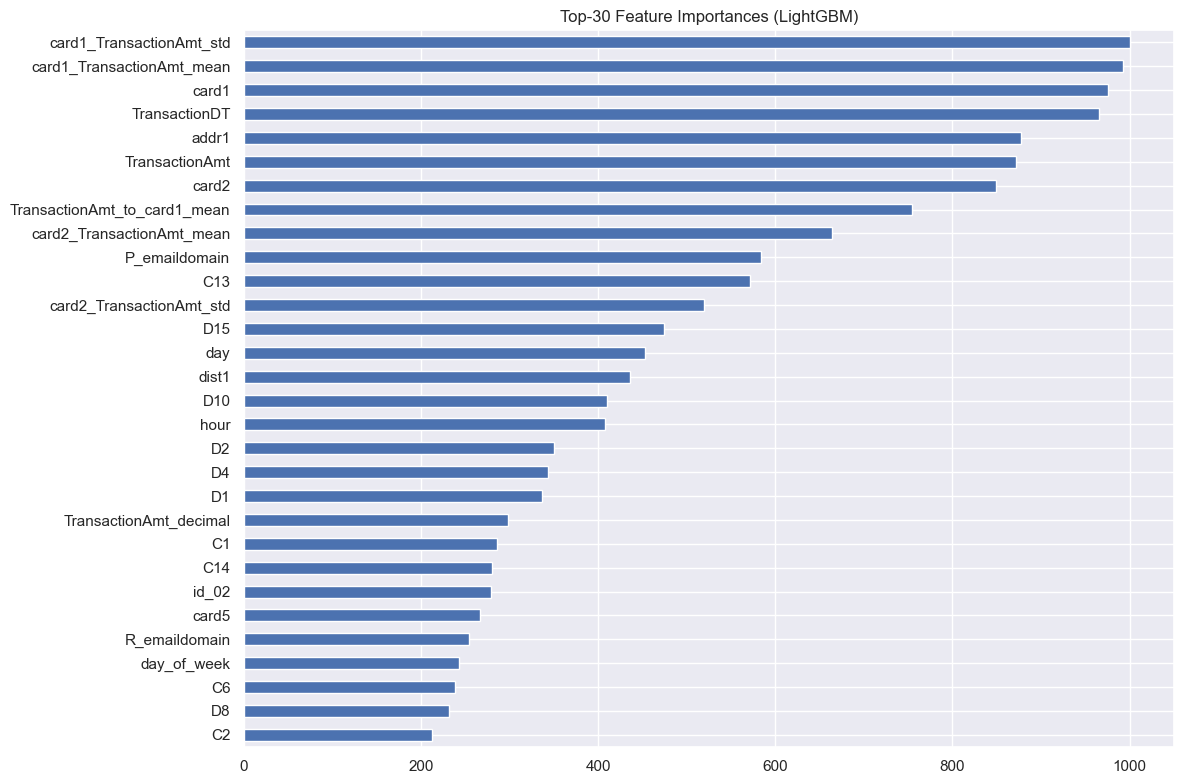

In [32]:
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.title('Top-30 Feature Importances (LightGBM)')
feat_imp[:30].plot(kind='barh')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Предсказание и сохранение submission

In [33]:
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_preds,
})

submission.to_csv('submission.csv', index=False)
print("Submission saved: submission.csv")
print(submission.head(10))
print(f"\nShape: {submission.shape}")
print(f"Prediction stats:\n{submission['isFraud'].describe()}")

Submission saved: submission.csv
   TransactionID   isFraud
0        3404559  0.023803
1        3404560  0.635980
2        3404561  0.090889
3        3404562  0.055721
4        3404563  0.563207
5        3404564  0.279283
6        3404565  0.025260
7        3404566  0.186253
8        3404567  0.013613
9        3404568  0.597296

Shape: (172981, 2)
Prediction stats:
count    172981.000000
mean          0.104396
std           0.164396
min           0.001648
25%           0.017848
50%           0.040974
75%           0.109774
max           0.989509
Name: isFraud, dtype: float64
